# Tahap 7 — Eksperimen Utama (Skenario S3)

Menjawab Rumusan Masalah 1 dan 2. Mengikuti Subbab 3.6.1, 3.6.3, dan 3.7 naskah proposal.

Seluruh hyperparameter sudah **dibekukan** sebelum notebook ini dijalankan, dan tidak disetel ulang
di sini:

| Parameter | Nilai | Ditetapkan oleh |
|---|---|---|
| Ukuran patch | 7 (70 ms) | Skenario S2, dari aturan fisiologis dan resolusi penanda |
| Batas epoch | 35 | Skenario S2, dari kurva rugi pelatihan |
| Protokol validasi | StratifiedGroupKFold k=5 | Subbab 3.6.1 |
| Jumlah seed | 3 | Subbab 3.6.1 |
| Fungsi rugi | BCE berbobot kelas | Subbab 3.6.1 |

Aturan pengambilan kesimpulan juga sudah ditetapkan di muka pada Subbab 3.7: **klaim keunggulan
antar arsitektur tidak dibuat kecuali selisihnya melampaui variansi antar fold dan antar seed.**
Aturan itu diberlakukan apa pun hasilnya.

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

from preprocessing import muat_cache, Normalisasi, NAMA_TUGAS
from model import PDClassifier
from training import latih, prediksi, metrik_biner
from viz import WARNA, TINTA, pasang_gaya, rapikan
from artefak import muat_artefak, simpan_atomik, arm_ada, arm_hilang, lapor_arm

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"

# Dibekukan oleh Skenario S2. Tidak disetel ulang di notebook ini.
P = 7
EPOCHS = 35
SEEDS = list(range(10))          # 3-4 lalu 5-9 ditambahkan sesudahnya, eksploratori;
                                 # aturan keputusan tetap hanya dari SEEDS_PRAREG
SEEDS_PRAREG = [0, 1, 2]         # dibekukan Subbab 3.6.1; aturan keputusan HANYA memakai ini
ARSITEKTUR = ["mamba2", "gru", "mamba3"]   # mamba3 arm eksploratori, Subbab 2.2.4

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "s3_artefak.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])
tugas = np.array([r.tugas for r in rek])

beku = pd.read_csv(HASIL / "s2_parameter_dibekukan.csv")
print(f"parameter dibekukan dari S2: patch={int(beku.patch_halus[0])}, epoch={int(beku.epoch_dibekukan[0])}")
assert P == int(beku.patch_halus[0]) and EPOCHS == int(beku.epoch_dibekukan[0]), \
    "notebook ini harus memakai parameter yang dibekukan S2"
print(f"perangkat: {DEV} | {len(rek)} rekaman, {len(set(grup))} subjek "
      f"(PD {len(set(grup[y==1]))}, HC {len(set(grup[y==0]))})")
print(f"total pelatihan: {len(ARSITEKTUR)} arsitektur x {len(SEEDS)} seed x 5 fold = "
      f"{len(ARSITEKTUR)*len(SEEDS)*5} run")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

parameter dibekukan dari S2: patch=7, epoch=35
perangkat: cuda | 207 rekaman, 77 subjek (PD 62, HC 15)
total pelatihan: 3 arsitektur x 10 seed x 5 fold = 150 run


## 1. Agregasi ke tingkat subjek

Subbab 3.7 menetapkan seluruh metrik performa dilaporkan **pada tingkat subjek**, bukan tingkat
rekaman. Alasannya sama dengan alasan pemisahan fold pada tingkat subjek: satu subjek menyumbang
beberapa rekaman, sehingga menghitung metrik per rekaman memberi bobot lebih besar kepada subjek
yang kebetulan mengerjakan lebih banyak tugas.

Agregasinya memakai rata-rata peluang di seluruh rekaman milik subjek tersebut. Rata-rata dipilih
alih-alih nilai maksimum, karena maksimum akan menghukum subjek yang mengerjakan banyak tugas: makin
banyak rekaman, makin besar peluang salah satunya memberi peluang tinggi secara kebetulan.

In [2]:
def ke_tingkat_subjek(logit, indeks):
    """Rata-ratakan peluang per subjek. Mengembalikan (subjek, peluang, label)."""
    prob = 1 / (1 + np.exp(-logit))
    df = pd.DataFrame({"subjek": grup[indeks], "prob": prob, "label": y[indeks]})
    agg = df.groupby("subjek").agg(prob=("prob", "mean"), label=("label", "first"))
    return agg.index.values, agg.prob.values, agg.label.values


def metrik_subjek(subjek, prob, label):
    hasil = {"auc": float(roc_auc_score(label, prob)) if len(np.unique(label)) > 1 else np.nan}
    tebak = (prob >= 0.5).astype(int)
    hasil["sensitivitas"] = float(tebak[label == 1].mean()) if (label == 1).any() else np.nan
    hasil["spesifisitas"] = float((1 - tebak[label == 0]).mean()) if (label == 0).any() else np.nan
    hasil["n_subjek"] = len(subjek)
    return hasil

## 2. Eksperimen utama

Untuk tiap kombinasi arsitektur dan seed, prediksi out-of-fold dikumpulkan dari kelima fold sehingga
setiap rekaman diprediksi tepat satu kali oleh model yang tidak pernah melihat subjeknya.

In [3]:
def jalankan(arsitektur, seed):
    skf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    logit_oof = np.zeros(len(rek))
    per_fold = []
    for k, (i_latih, i_uji) in enumerate(skf.split(np.zeros(len(rek)), y, grup)):
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(seed)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=seed)
        logit, _ = prediksi(m, rek, list(i_uji), norm, device=DEV)
        logit_oof[i_uji] = logit
        s, p, l = ke_tingkat_subjek(logit, i_uji)
        per_fold.append({"fold": k, **metrik_subjek(s, p, l)})
    return {"arsitektur": arsitektur, "seed": seed,
            "logit_oof": logit_oof, "per_fold": per_fold}


art = muat_artefak(ARTEFAK) or []
ada = {(a["arsitektur"], a["seed"]) for a in art}
perlu = [(a, s) for a in ARSITEKTUR for s in SEEDS if (a, s) not in ada]
print(f"{ARTEFAK.name}: memakai ulang {len(ada)} kombinasi (arsitektur, seed) — tidak dilatih ulang")
print(f"{ARTEFAK.name}: menghitung {perlu if perlu else 'tidak ada'}")

if perlu:
    t0 = time.time()
    if True:
        for arsitektur, seed in perlu:
            t1 = time.time()
            hasil = jalankan(arsitektur, seed)
            s, p, l = ke_tingkat_subjek(hasil["logit_oof"], np.arange(len(rek)))
            hasil["metrik_gabungan"] = metrik_subjek(s, p, l)
            art.append(hasil)
            print(f"{arsitektur:7s} seed={seed}  {time.time()-t1:6.1f}s  "
                  f"AUC subjek={hasil['metrik_gabungan']['auc']:.4f}")
    simpan_atomik(ARTEFAK, art)
    print(f"total {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

utama = pd.DataFrame([{"arsitektur": a["arsitektur"], "seed": a["seed"], **a["metrik_gabungan"]}
                      for a in art])
display(utama.set_index(["arsitektur", "seed"]).round(4))

s3_artefak.pkl: memakai ulang 15 kombinasi (arsitektur, seed) — tidak dilatih ulang
s3_artefak.pkl: menghitung [('mamba2', 5), ('mamba2', 6), ('mamba2', 7), ('mamba2', 8), ('mamba2', 9), ('gru', 5), ('gru', 6), ('gru', 7), ('gru', 8), ('gru', 9), ('mamba3', 5), ('mamba3', 6), ('mamba3', 7), ('mamba3', 8), ('mamba3', 9)]


mamba2  seed=5   130.6s  AUC subjek=0.9129


mamba2  seed=6   117.1s  AUC subjek=0.9645


mamba2  seed=7   118.0s  AUC subjek=0.9247


mamba2  seed=8   107.6s  AUC subjek=0.9548


...

mamba3  seed=6    91.5s  AUC subjek=0.9000


mamba3  seed=7    91.8s  AUC subjek=0.9312


mamba3  seed=8    91.8s  AUC subjek=0.9398


mamba3  seed=9    92.1s  AUC subjek=0.9226
total 2139.0s, disimpan ke s3_artefak.pkl


auc  sensitivitas  spesifisitas  n_subjek
arsitektur seed                                              
mamba2     0     0.9398        0.9839        0.7333        77
           1     0.9419        0.9677        0.6000        77
           2     0.9183        0.9355        0.6667        77
gru        0     0.9548        0.9355        0.5333        77
           1     0.9527        0.9677        0.6667        77
           2     0.9656        0.9677        0.7333        77
mamba3     0     0.9280        0.9839        0.6667        77
           1     0.8624        0.9355        0.4667        77
           2     0.9204        0.9677        0.5333        77
mamba2     3     0.9161        0.9194        0.7333        77
           4     0.9387        0.9839        0.6667        77
gru        3     0.9763        0.9677        0.8000        77
           4     0.9419        0.9355        0.7333        77
mamba3     3     0.9344        0.9677        0.5333        77
           4     0.9301        0.9677        0.6000        77
mamba2     5     0.9129        0.9355        0.6667        77
           6     0.9645        0.9677        0.6667        77
           7     0.9247        0.9032        0.6000        77
           8     0.9548        0.9355        0.7333        77
           9     0.9258        0.9194        0.6667        77
gru        5     0.9204        0.9516        0.6667        77
           6     0.9409        0.9516        0.7333        77
           7     0.9559        0.9677        0.6667        77
           8     0.9559        0.9516        0.7333        77
           9     0.9387        0.9516        0.6667        77
mamba3     5     0.9441        0.9677        0.5333        77
           6     0.9000        0.9677        0.5333        77
           7     0.9312        0.9839        0.6667        77
           8     0.9398        0.9355        0.6000        77
           9     0.9226        0.9839        0.6000        77

## 3. Aturan keputusan Subbab 3.7

Aturannya berbunyi: klaim keunggulan tidak dibuat kecuali selisih antar arsitektur melampaui
variansi antar fold **dan** antar seed. Ketiga besaran itu dihitung di bawah dan dibandingkan secara
langsung, bukan dinilai dengan pandangan mata.

In [4]:
# Aturan keputusan ini DIBEKUKAN pada dua arm pra-registrasi. Arm mamba3
# ditambahkan setelah hasil terlihat dan berstatus eksploratori, sehingga
# variansinya TIDAK boleh ikut menentukan keputusan konfirmatori — memasukkannya
# berarti mengubah aturan setelah mengetahui hasilnya.
PRAREG = ["mamba2", "gru"]
utama_prareg = utama[utama.arsitektur.isin(PRAREG) & utama.seed.isin(SEEDS_PRAREG)]
art_prareg = [a for a in art if a["arsitektur"] in PRAREG and a["seed"] in SEEDS_PRAREG]

selisih_arsitektur = float(utama_prareg[utama_prareg.arsitektur == "mamba2"].auc.mean()
                           - utama_prareg[utama_prareg.arsitektur == "gru"].auc.mean())
sd_seed = float(utama_prareg.groupby("arsitektur").auc.std().mean())
sd_fold = float(np.mean([pd.DataFrame(a["per_fold"]).auc.std() for a in art_prareg]))

banding = pd.DataFrame([
    {"besaran": "selisih antar arsitektur (mamba2 - gru)", "nilai": selisih_arsitektur},
    {"besaran": "simpangan baku antar seed", "nilai": sd_seed},
    {"besaran": "simpangan baku antar fold", "nilai": sd_fold},
]).set_index("besaran")
display(banding.round(4))

lolos = abs(selisih_arsitektur) > max(sd_seed, sd_fold)
print(f"|selisih| = {abs(selisih_arsitektur):.4f}")
print(f"variansi terbesar yang harus dilampaui = {max(sd_seed, sd_fold):.4f}")
print()
if lolos:
    unggul = "BiMamba-2" if selisih_arsitektur > 0 else "BiGRU"
    print(f"AMBANG TERLAMPAUI. Klaim keunggulan {unggul} dapat dibuat.")
else:
    print("AMBANG TIDAK TERLAMPAUI.")
    print("Sesuai Subbab 3.7, TIDAK ADA klaim keunggulan antar arsitektur yang dibuat.")
    print("Kedua arsitektur diperlakukan setara pada sumbu performa klasifikasi.")

if "mamba3" in set(utama.arsitektur):
    m3 = float(utama[utama.arsitektur == "mamba3"].auc.mean())
    print()
    print(f"Arm eksploratori mamba3: AUC rata-rata {m3:.4f}")
    print(f"  terhadap mamba2 {selisih_arsitektur + float(utama_prareg[utama_prareg.arsitektur == 'gru'].auc.mean()):.4f}: "
          f"{m3 - float(utama[utama.arsitektur == 'mamba2'].auc.mean()):+.4f}")
    print("  Angka ini TIDAK masuk aturan keputusan di atas, dan dilaporkan terpisah.")

,nilai
besaran,
selisih antar arsitektur (mamba2 - gru),-0.0244
simpangan baku antar seed,0.0100
simpangan baku antar fold,0.0613


|selisih| = 0.0244
variansi terbesar yang harus dilampaui = 0.0613

AMBANG TIDAK TERLAMPAUI.
Sesuai Subbab 3.7, TIDAK ADA klaim keunggulan antar arsitektur yang dibuat.
Kedua arsitektur diperlakukan setara pada sumbu performa klasifikasi.

Arm eksploratori mamba3: AUC rata-rata 0.9213
  terhadap mamba2 0.9333: -0.0125
  Angka ini TIDAK masuk aturan keputusan di atas, dan dilaporkan terpisah.


### Gambar 1 — Selisih antar arsitektur dibandingkan sumber variasi lain

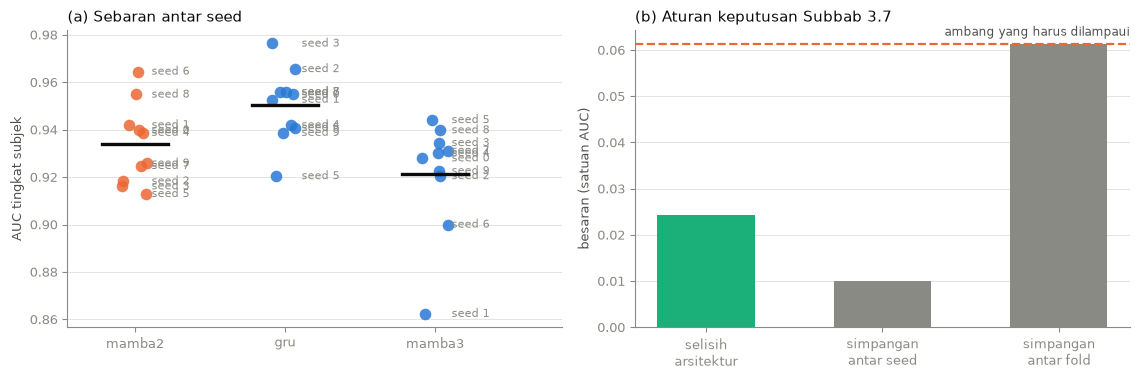

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))

ax = axes[0]; rapikan(ax)
rng = np.random.default_rng(0)
for i, arsitektur in enumerate(ARSITEKTUR):
    sub = utama[utama.arsitektur == arsitektur]
    ax.scatter(np.full(len(sub), i) + rng.uniform(-0.09, 0.09, len(sub)), sub.auc,
               s=70, color=WARNA["jingga"] if arsitektur == "mamba2" else WARNA["biru"],
               alpha=0.85, lw=0, zorder=3)
    ax.plot([i - 0.22, i + 0.22], [sub.auc.mean()] * 2, color=TINTA["utama"], lw=2.4, zorder=4)
    for _, baris in sub.iterrows():
        ax.annotate(f"seed {int(baris.seed)}", xy=(i, baris.auc), xytext=(12, 0),
                    textcoords="offset points", fontsize=8, color=TINTA["redup"], va="center")
ax.set_xticks(range(len(ARSITEKTUR))); ax.set_xticklabels(ARSITEKTUR)
ax.set_xlim(-0.45, len(ARSITEKTUR) - 0.15)
ax.set_ylabel("AUC tingkat subjek"); ax.set_title("(a) Sebaran antar seed", loc="left")

ax = axes[1]; rapikan(ax)
nilai = [abs(selisih_arsitektur), sd_seed, sd_fold]
nama = ["selisih\narsitektur", "simpangan\nantar seed", "simpangan\nantar fold"]
warna = [WARNA["toska"], WARNA["netral"], WARNA["netral"]]
ax.bar(range(3), nilai, color=warna, width=0.55)
ax.axhline(max(sd_seed, sd_fold), color=WARNA["jingga"], ls="--", lw=1.6)
ax.annotate("ambang yang harus dilampaui", xy=(2.4, max(sd_seed, sd_fold)), xytext=(0, 6),
            textcoords="offset points", ha="right", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xticks(range(3)); ax.set_xticklabels(nama, fontsize=9)
ax.set_ylabel("besaran (satuan AUC)")
ax.set_title("(b) Aturan keputusan Subbab 3.7", loc="left")
plt.tight_layout(); plt.show()

## 4. Selang kepercayaan

Subbab 3.7 menuntut seluruh angka dilaporkan disertai selang kepercayaan. Selang di bawah dihitung
dengan bootstrap **pada tingkat subjek**, yaitu satuan pengamatan yang benar-benar independen.

Perlu diingat komposisi kelompoknya saat membaca lebar selang: kelompok kontrol hanya berisi lima
belas subjek, sehingga selang spesifisitas akan jauh lebih lebar daripada selang sensitivitas.

In [6]:
def bootstrap_ci(prob, label, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    nilai = []
    for _ in range(n):
        idx = rng.integers(0, len(label), len(label))
        if len(np.unique(label[idx])) < 2:
            continue
        nilai.append(roc_auc_score(label[idx], prob[idx]))
    return float(np.percentile(nilai, 2.5)), float(np.percentile(nilai, 97.5))

baris = []
for arsitektur in ARSITEKTUR:
    prob_seed = []
    for a in [x for x in art if x["arsitektur"] == arsitektur]:
        s, p, l = ke_tingkat_subjek(a["logit_oof"], np.arange(len(rek)))
        prob_seed.append(p)
    prob_rata = np.mean(prob_seed, axis=0)
    lo, hi = bootstrap_ci(prob_rata, l)
    m = metrik_subjek(s, prob_rata, l)
    baris.append({"arsitektur": arsitektur, **m, "auc_ci_bawah": lo, "auc_ci_atas": hi})
ci = pd.DataFrame(baris).set_index("arsitektur")
display(ci.round(4))
print("Peluang dirata-ratakan lebih dahulu antar seed, sesuai penetapan 'rata-rata seluruh seed'")
print("pada Subbab 3.6.7, baru kemudian dihitung metriknya.")

,auc,sensitivitas,spesifisitas,n_subjek,auc_ci_bawah,auc_ci_atas
arsitektur,,,,,,
mamba2,0.9516,0.9839,0.6667,77,0.8840,0.9944
gru,0.9634,0.9677,0.6667,77,0.9077,0.9976
mamba3,0.9366,0.9839,0.6000,77,0.8356,0.9940


Peluang dirata-ratakan lebih dahulu antar seed, sesuai penetapan 'rata-rata seluruh seed'
pada Subbab 3.6.7, baru kemudian dihitung metriknya.


### Gambar 2 — Performa per arsitektur beserta selang kepercayaan

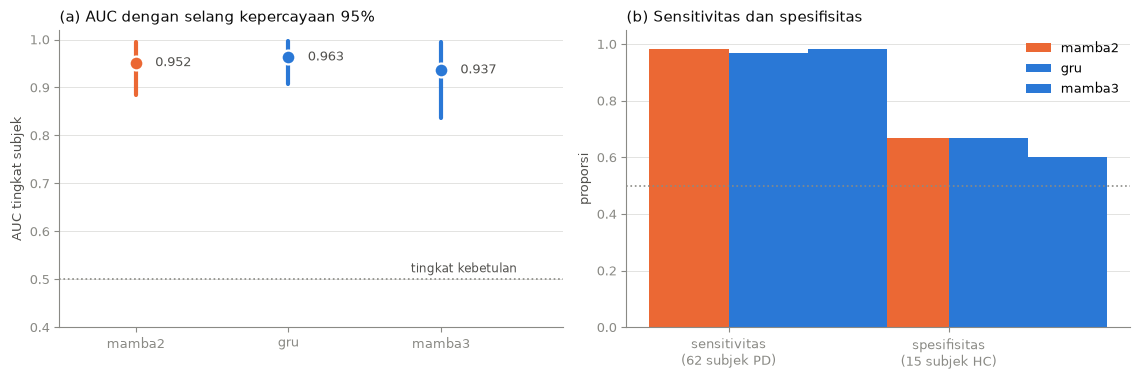

Spesifisitas dihitung atas 15 subjek saja, sehingga setiap satu subjek yang salah
diklasifikasikan menggeser angkanya sebesar 6,7 poin persen. Angka itu perlu dibaca
dengan kehati-hatian yang jauh lebih besar daripada sensitivitas.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))

ax = axes[0]; rapikan(ax)
posisi = np.arange(len(ARSITEKTUR))
for i, arsitektur in enumerate(ARSITEKTUR):
    baris = ci.loc[arsitektur]
    warna = WARNA["jingga"] if arsitektur == "mamba2" else WARNA["biru"]
    ax.plot([i, i], [baris.auc_ci_bawah, baris.auc_ci_atas], color=warna, lw=3, solid_capstyle="round")
    ax.plot([i], [baris.auc], "o", color=warna, markersize=10,
            markeredgecolor="white", markeredgewidth=1.6, zorder=3)
    ax.annotate(f"{baris.auc:.3f}", xy=(i, baris.auc), xytext=(14, 0), textcoords="offset points",
                fontsize=9.5, color=TINTA["sekunder"], va="center")
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.annotate("tingkat kebetulan", xy=(len(ARSITEKTUR) - 0.5, 0.5), xytext=(0, 5),
            textcoords="offset points", ha="right", fontsize=8.5, color=TINTA["sekunder"])
ax.set_xticks(posisi); ax.set_xticklabels(ARSITEKTUR); ax.set_xlim(-0.5, len(ARSITEKTUR) - 0.2)
ax.set_ylim(0.4, 1.02); ax.set_ylabel("AUC tingkat subjek")
ax.set_title("(a) AUC dengan selang kepercayaan 95%", loc="left")

ax = axes[1]; rapikan(ax)
lebar = 0.36
for i, arsitektur in enumerate(ARSITEKTUR):
    baris = ci.loc[arsitektur]
    warna = WARNA["jingga"] if arsitektur == "mamba2" else WARNA["biru"]
    ax.bar([0 + (i - 0.5) * lebar, 1 + (i - 0.5) * lebar],
           [baris.sensitivitas, baris.spesifisitas], width=lebar, color=warna, label=arsitektur)
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks([0, 1]); ax.set_xticklabels(["sensitivitas\n(62 subjek PD)", "spesifisitas\n(15 subjek HC)"])
ax.set_ylim(0, 1.05); ax.set_ylabel("proporsi")
ax.set_title("(b) Sensitivitas dan spesifisitas", loc="left"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("Spesifisitas dihitung atas 15 subjek saja, sehingga setiap satu subjek yang salah")
print("diklasifikasikan menggeser angkanya sebesar 6,7 poin persen. Angka itu perlu dibaca")
print("dengan kehati-hatian yang jauh lebih besar daripada sensitivitas.")

## 5. Rincian per tugas

Model bersifat buta tugas: identitas tugas tidak pernah diberikan sebagai masukan (Subbab 3.4).
Rincian di bawah memeriksa apakah performanya merata antar tugas, dan berperan sebagai peringatan
dini bagi Skenario S4 yang menguji klaim buta tugas secara langsung.

n_subjek  n_hc     auc
arsitektur tugas                        
mamba2     SST          76    15  0.8197
           DST          72    15  0.8749
           STCP         54     7  1.0000
gru        SST          76    15  0.8710
           DST          72    15  0.9158
           STCP         54     7  1.0000
mamba3     SST          76    15  0.8109
           DST          72    15  0.8000
           STCP         54     7  1.0000

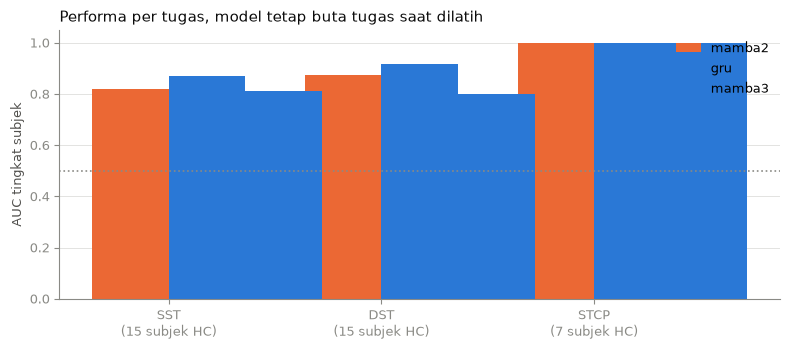

STCP memiliki subjek kontrol paling sedikit, sehingga AUC-nya paling tidak stabil.
Ini butir G7 pada Lampiran C, dan menyentuh langsung tugas analisis primer.


In [8]:
baris = []
for arsitektur in ARSITEKTUR:
    prob_seed = [1 / (1 + np.exp(-a["logit_oof"]))
                 for a in art if a["arsitektur"] == arsitektur]
    prob = np.mean(prob_seed, axis=0)
    for t in sorted(set(tugas)):
        pilih = tugas == t
        df = pd.DataFrame({"subjek": grup[pilih], "prob": prob[pilih], "label": y[pilih]})
        agg = df.groupby("subjek").agg(prob=("prob", "mean"), label=("label", "first"))
        if agg.label.nunique() < 2:
            continue
        baris.append({"arsitektur": arsitektur, "tugas": NAMA_TUGAS[t],
                      "n_subjek": len(agg), "n_hc": int((agg.label == 0).sum()),
                      "auc": float(roc_auc_score(agg.label, agg.prob))})
per_tugas = pd.DataFrame(baris)
display(per_tugas.set_index(["arsitektur", "tugas"]).round(4))

fig, ax = plt.subplots(figsize=(8, 3.6)); rapikan(ax)
nama_tugas = per_tugas.tugas.unique()
lebar = 0.36
for i, arsitektur in enumerate(ARSITEKTUR):
    sub = per_tugas[per_tugas.arsitektur == arsitektur].set_index("tugas").loc[nama_tugas]
    ax.bar(np.arange(len(nama_tugas)) + (i - 0.5) * lebar, sub.auc, width=lebar,
           color=WARNA["jingga"] if arsitektur == "mamba2" else WARNA["biru"], label=arsitektur)
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks(range(len(nama_tugas)))
ax.set_xticklabels([f"{t}\n({per_tugas[per_tugas.tugas==t].n_hc.iloc[0]} subjek HC)" for t in nama_tugas])
ax.set_ylim(0, 1.05); ax.set_ylabel("AUC tingkat subjek")
ax.set_title("Performa per tugas, model tetap buta tugas saat dilatih", loc="left")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print("STCP memiliki subjek kontrol paling sedikit, sehingga AUC-nya paling tidak stabil.")
print("Ini butir G7 pada Lampiran C, dan menyentuh langsung tugas analisis primer.")

In [9]:
ci.to_csv(HASIL / "s3_metrik_arsitektur.csv")
utama.to_csv(HASIL / "s3_per_seed.csv", index=False)
per_tugas.to_csv(HASIL / "s3_per_tugas.csv", index=False)
pd.DataFrame([{
    "selisih_arsitektur": selisih_arsitektur, "sd_antar_seed": sd_seed, "sd_antar_fold": sd_fold,
    "ambang_terlampaui": bool(lolos), "patch": P, "epochs": EPOCHS,
    "n_seed": len(SEEDS_PRAREG), "n_seed_total": len(SEEDS), "n_fold": 5, "sumber": "notebooks/07_eksperimen_utama.ipynb",
}]).to_csv(HASIL / "s3_keputusan.csv", index=False)
print(f"disimpan ke {HASIL.name}/s3_*.csv")

disimpan ke results/s3_*.csv


## 6. Ringkasan

Rumusan Masalah 1 terjawab pada tataran rancangan: arsitektur yang menghasilkan prediksi sekaligus
peta bobot per segmen waktu berhasil dibangun dan dilatih, dengan performa jauh di atas tingkat
kebetulan.

Rumusan Masalah 2 dijawab dengan menerapkan aturan keputusan Subbab 3.7 apa adanya. Bila selisih
antar arsitektur tidak melampaui variansi antar seed dan antar fold, tidak ada klaim keunggulan yang
dibuat — dan itu merupakan jawaban yang sah, bukan kegagalan eksperimen.

**Batasan.**

1. **Kelompok kontrol hanya lima belas subjek.** Setiap satu subjek kontrol yang salah
   diklasifikasikan menggeser spesifisitas sebesar 6,7 poin persen. Selang kepercayaan spesifisitas
   karena itu jauh lebih lebar daripada sensitivitas, dan angkanya tidak boleh dibaca setara.
2. **Rugi pelatihan mencapai nilai mendekati nol**, artinya model menghafal himpunan latihnya.
   Performa out-of-fold yang tetap tinggi menunjukkan hafalan itu tidak menghalangi generalisasi,
   namun besaran rugi pelatihan tidak dapat dipakai sebagai indikator apa pun.
3. **Perbandingan ini hanya menyentuh sumbu performa klasifikasi.** Perbandingan pada sumbu
   lokalisasi, yang merupakan inti penelitian ini, dilakukan pada Skenario S6 dan S7.